# Playground Series S6E9 — Predicting Electric Vehicle Purchases

**Goal:** For each person in the test set, predict the *probability* that they will buy an electric vehicle (`Will_Buy_EV`).

**Evaluation metric:** ROC-AUC (Area Under the ROC Curve) — explained below.

This notebook is written as a tutorial. Every section explains the *concept* before the code that implements it. Run the cells top to bottom.


## 1. Why is this "binary classification"?

Machine learning problems are usually split into:

- **Regression** — predict a continuous number (e.g. house price, temperature).
- **Classification** — predict a category/label. If there are exactly 2 possible labels, it's called **binary classification**. If there are 3+, it's **multi-class classification**.

Our target column, `Will_Buy_EV`, only ever takes the value `"Yes"` or `"No"` — two categories. That makes this binary classification.

## 2. Why ROC-AUC as a metric, and what is it?

A naive metric would be **accuracy**: the fraction of predictions you got exactly right. But accuracy is a bad idea here because the classes are **imbalanced** — only ~17.5% of people in the training data actually buy an EV. A lazy model that *always* predicts "No" would already be ~82.5% accurate while being completely useless.

**ROC-AUC** fixes this by measuring how well the model *ranks* positive cases above negative cases, across every possible probability threshold, rather than requiring one fixed cutoff:

- **ROC curve**: plots the True Positive Rate (TPR, i.e. recall — of all actual buyers, what fraction did we catch?) against the False Positive Rate (FPR — of all actual non-buyers, what fraction did we wrongly flag?) as you sweep the decision threshold from 0 to 1.
- **AUC** (Area Under that Curve): a single number from 0 to 1.
  - 0.5 = no better than random guessing.
  - 1.0 = perfect separation between classes.
  - In practice, tabular Kaggle competitions like this often land in the 0.75–0.95 range.

Because Kaggle wants a *probability* per row (not a hard Yes/No), and scores it with AUC, our job is to output well-**ranked** probabilities — a person we think is 90% likely to buy should score higher than one we think is 20% likely.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve

import lightgbm as lgb

RANDOM_STATE = 42
pd.set_option("display.max_columns", None)


## 3. Load and inspect the data

Before modeling anything, we always look at the raw data first: how big is it, what are the columns, are there missing values, and what does the target distribution look like?


In [2]:
train = pd.read_csv("../data/train.csv")
test = pd.read_csv("../data/test.csv")

print("train shape:", train.shape)
print("test shape:", test.shape)
train.head()


train shape: (668665, 15)
test shape: (286571, 14)


,id,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,Gender,City_Type,Current_Car_Type,Home_Charging_Possible,Subsidy_Available,Range_Anxiety_Level,Will_Buy_EV
0,0,66,92887.0,23.4,2,3,7,1.0,Male,Suburban,Sedan,Yes,No,Low,No
1,1,38,30000.0,5.0,1,2,2,4.0,Male,Rural,SUV,Yes,No,Low,No
2,2,26,94389.0,36.8,1,8,15,5.0,Female,Urban,Sedan,No,Yes,Low,Yes
3,3,66,73580.0,23.7,2,6,9,3.0,Male,Suburban,Hatchback,Yes,No,Low,No
4,4,54,57898.0,50.8,1,2,3,3.0,Male,Suburban,Hatchback,Yes,No,Low,No


In [3]:
train.info()


<class 'pandas.DataFrame'>
RangeIndex: 668665 entries, 0 to 668664
Data columns (total 15 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   id                           668665 non-null  int64  
 1   Age                          668665 non-null  int64  
 2   Annual_Income_USD            668665 non-null  float64
 3   Daily_Commute_km             668665 non-null  float64
 4   Number_of_Cars_Owned         668665 non-null  int64  
 5   Charging_Stations_Near_Home  668665 non-null  int64  
 6   Charging_Stations_Near_Work  668665 non-null  int64  
 7   Environmental_Concern_Level  668665 non-null  float64
 8   Gender                       668665 non-null  str    
 9   City_Type                    668665 non-null  str    
 10  Current_Car_Type             668665 non-null  str    
 11  Home_Charging_Possible       668665 non-null  str    
 12  Subsidy_Available            668665 non-null  str    
 13  Range_Anxi

In [4]:
# Missing values?
train.isnull().sum()


id                             0
Age                            0
Annual_Income_USD              0
Daily_Commute_km               0
Number_of_Cars_Owned           0
Charging_Stations_Near_Home    0
Charging_Stations_Near_Work    0
Environmental_Concern_Level    0
Gender                         0
City_Type                      0
Current_Car_Type               0
Home_Charging_Possible         0
Subsidy_Available              0
Range_Anxiety_Level            0
Will_Buy_EV                    0
dtype: int64

Will_Buy_EV
No     551886
Yes    116779
Name: count, dtype: int64

Will_Buy_EV
No     0.825355
Yes    0.174645
Name: proportion, dtype: float64


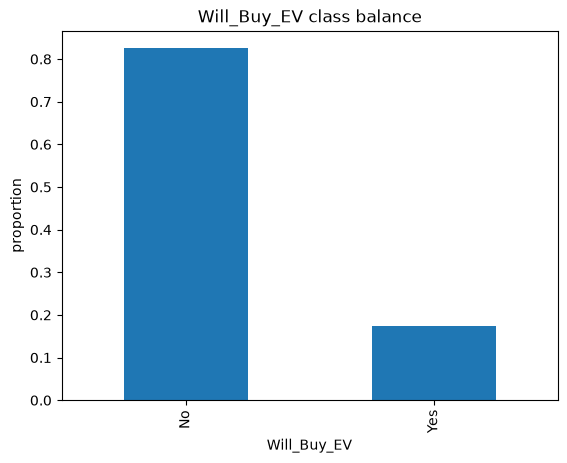

In [5]:
# Target balance
target_counts = train["Will_Buy_EV"].value_counts()
target_rate = train["Will_Buy_EV"].value_counts(normalize=True)
print(target_counts)
print()
print(target_rate)

target_rate.plot(kind="bar", title="Will_Buy_EV class balance")
plt.ylabel("proportion")
plt.show()


Notice the imbalance: roughly 1 in 6 people bought an EV. This confirms why ROC-AUC (rather than accuracy) is the right metric — and it's also a hint for later: some models benefit from being told about this imbalance (e.g. `scale_pos_weight` in LightGBM), which we'll try after the baseline.


## 4. Exploratory Data Analysis (EDA)

We separate columns into two kinds:

- **Numeric features**: `Age`, `Annual_Income_USD`, `Daily_Commute_km`, `Number_of_Cars_Owned`, `Charging_Stations_Near_Home`, `Charging_Stations_Near_Work`, `Environmental_Concern_Level`.
- **Categorical features**: `Gender`, `City_Type`, `Current_Car_Type`, `Home_Charging_Possible`, `Subsidy_Available`, `Range_Anxiety_Level`.

For numeric features, we plot their distribution split by target class — if the "Yes" and "No" distributions look different, that feature is likely predictive. For categorical features, we look at the EV-purchase rate within each category.


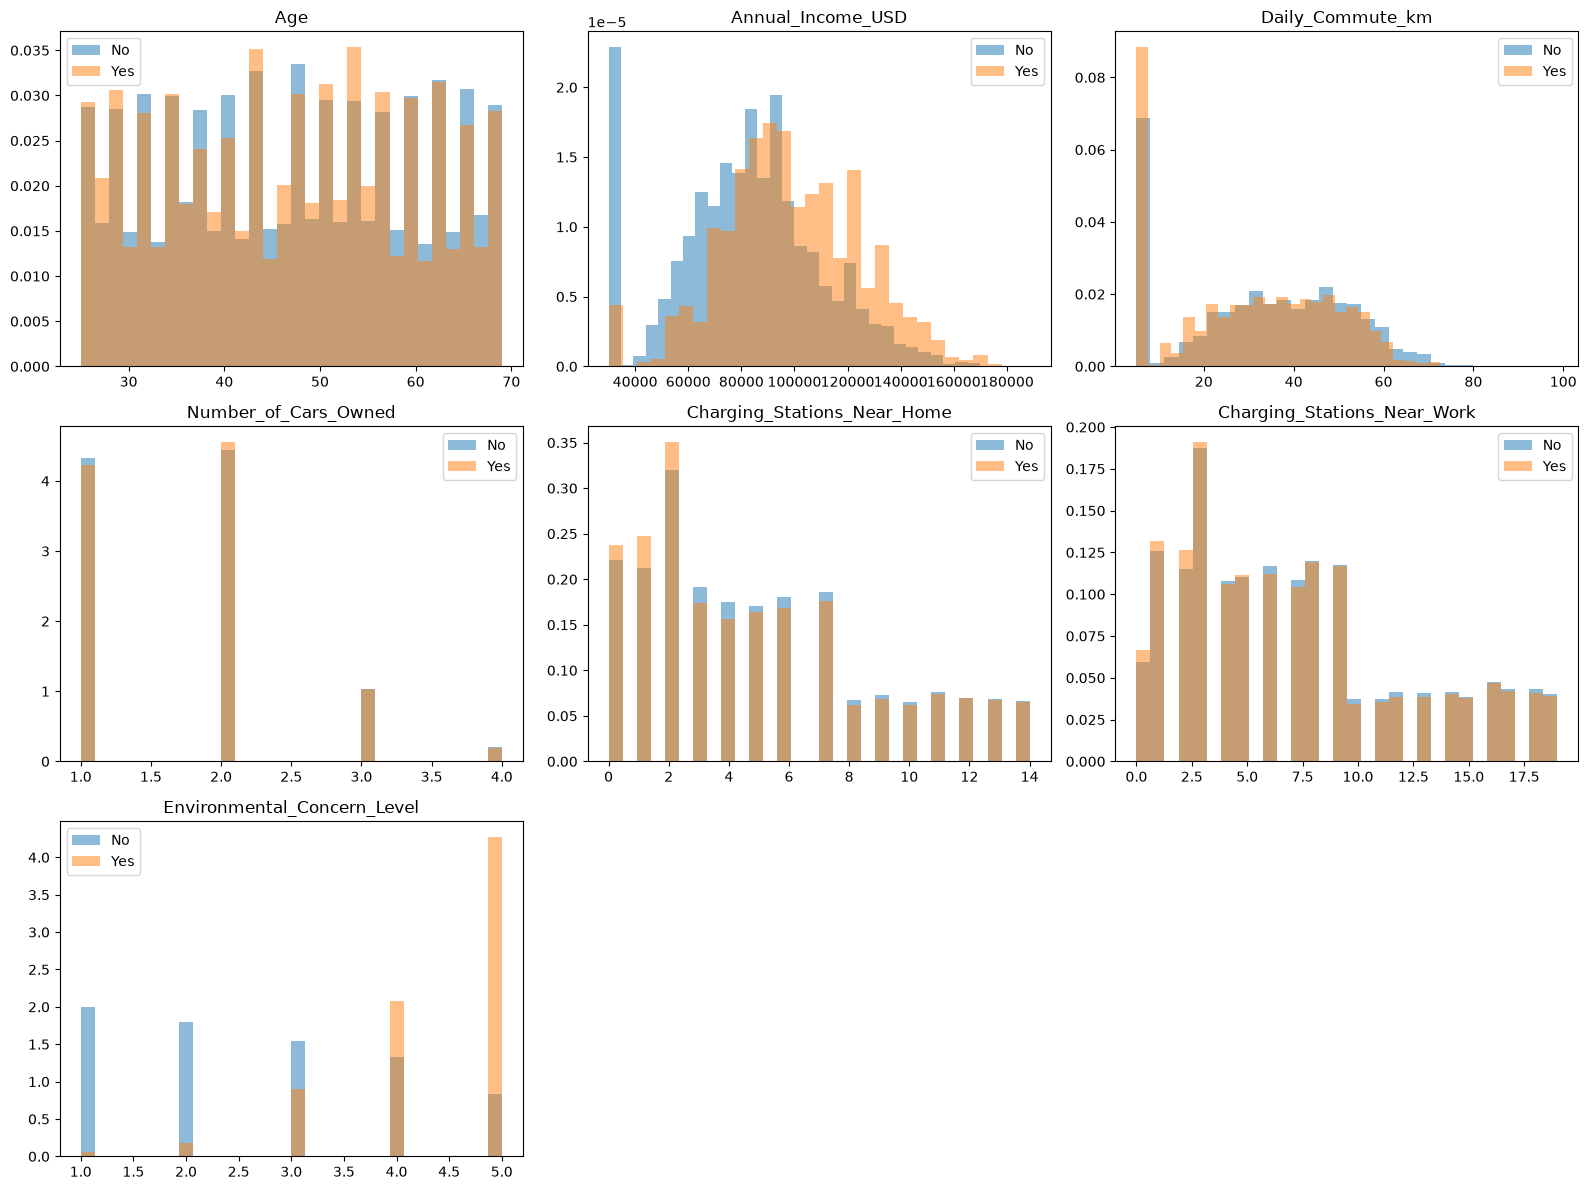

In [6]:
TARGET = "Will_Buy_EV"
ID_COL = "id"

numeric_features = [
    "Age", "Annual_Income_USD", "Daily_Commute_km", "Number_of_Cars_Owned",
    "Charging_Stations_Near_Home", "Charging_Stations_Near_Work",
    "Environmental_Concern_Level",
]
categorical_features = [
    "Gender", "City_Type", "Current_Car_Type",
    "Home_Charging_Possible", "Subsidy_Available", "Range_Anxiety_Level",
]

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.ravel()
for i, col in enumerate(numeric_features):
    for label, color in [("No", "tab:blue"), ("Yes", "tab:orange")]:
        subset = train.loc[train[TARGET] == label, col]
        axes[i].hist(subset, bins=30, alpha=0.5, label=label, color=color, density=True)
    axes[i].set_title(col)
    axes[i].legend()
for j in range(len(numeric_features), len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()


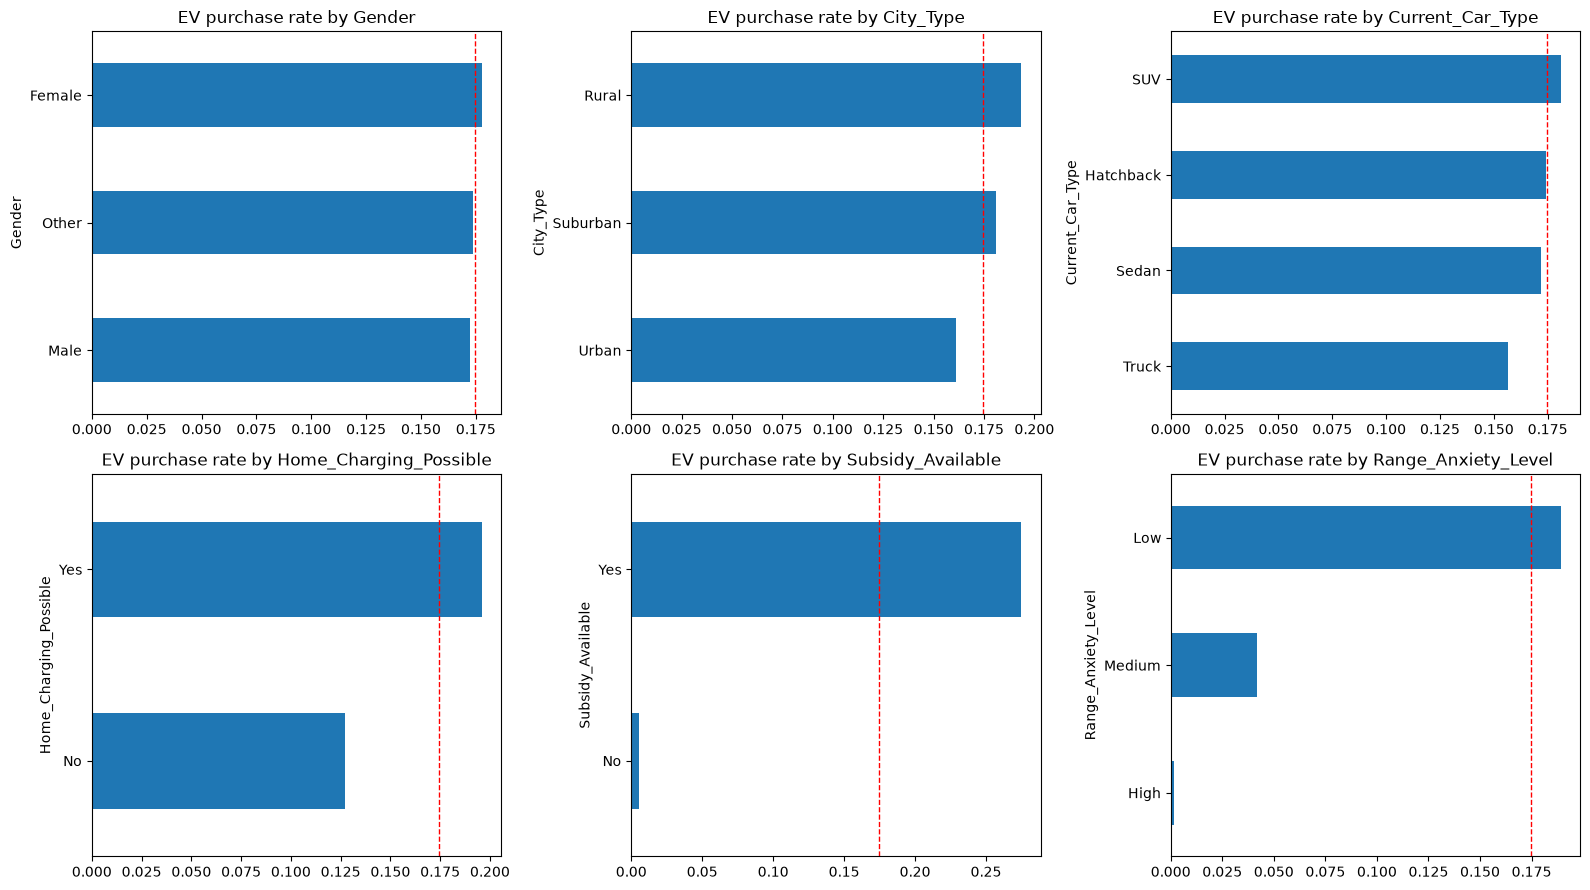

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.ravel()
for i, col in enumerate(categorical_features):
    rate = train.groupby(col)[TARGET].apply(lambda s: (s == "Yes").mean()).sort_values()
    rate.plot(kind="barh", ax=axes[i], title=f"EV purchase rate by {col}")
    axes[i].axvline(train[TARGET].eq("Yes").mean(), color="red", linestyle="--", linewidth=1)
plt.tight_layout()
plt.show()


The dashed red line is the overall average purchase rate. Categories whose bars extend well past that line (in either direction) are informative — e.g. we'd expect `Subsidy_Available = Yes` or low `Range_Anxiety_Level` to push the rate up, since both make EV ownership more attractive.


## 5. Train/validation split

`test.csv` has no labels — Kaggle keeps those hidden so we can't just tune against it. So before touching the test set, we carve out part of our *own* training data as a **validation set**: a chunk of labeled rows we hide from the model during training, then use afterward to estimate how well it generalizes to unseen data.

We use `train_test_split` with `stratify=y` — stratifying means the split preserves the ~17.5%/82.5% class ratio in both the training and validation portions, so the validation score isn't skewed by a lucky or unlucky split.


In [8]:
feature_cols = numeric_features + categorical_features

X = train[feature_cols].copy()
y = (train[TARGET] == "Yes").astype(int)  # encode Yes/No as 1/0

X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print(X_train.shape, X_valid.shape)


(534932, 13) (133733, 13)


## 6. Baseline Model 1: Logistic Regression

**Why start here?** Logistic Regression is one of the simplest classification models, and a great first baseline: it's fast, interpretable, and gives you a "floor" to beat with fancier models. If a complex model can't beat logistic regression, something's wrong.

**How it works, briefly:** it computes a weighted sum of your input features (like linear regression), then squashes that sum through the **sigmoid function** so the output is always between 0 and 1 — a probability. Training finds the feature weights that make its predicted probabilities match the actual outcomes as closely as possible.

**Categorical features problem:** Logistic Regression only understands numbers, but columns like `Gender` or `City_Type` are text categories. We fix this with **One-Hot Encoding**: each category becomes its own 0/1 column (e.g. `City_Type_Urban`, `City_Type_Suburban`, `City_Type_Rural`). This avoids implying a false order (Logistic Regression would otherwise treat "Rural=0, Suburban=1, Urban=2" as meaningfully ordered, which is wrong for categories with no natural order).

We wrap the encoding + model into a scikit-learn **Pipeline** so the exact same preprocessing is applied consistently to training, validation, and test data.


In [9]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ]
)

logreg_pipeline = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
])

logreg_pipeline.fit(X_train, y_train)

valid_probs_logreg = logreg_pipeline.predict_proba(X_valid)[:, 1]
auc_logreg = roc_auc_score(y_valid, valid_probs_logreg)
print(f"Logistic Regression validation AUC: {auc_logreg:.4f}")


Logistic Regression validation AUC: 0.9322


/Users/f/kaggle/playground-series-s6e9/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## 7. Baseline Model 2: LightGBM (Gradient Boosted Trees)

Tabular Kaggle competitions are almost always won (or nearly won) by **gradient boosted decision trees** — LightGBM and XGBoost are the two most popular implementations. Here's the intuition:

- A single **decision tree** repeatedly splits the data on feature thresholds (e.g. "Age > 40?") to separate classes — easy to overfit on its own.
- **Boosting** builds many small trees *sequentially*: each new tree is trained to correct the errors ("residuals") of the trees built so far, and their outputs are combined (a weighted sum passed through a sigmoid for classification).
- This ensemble approach handles non-linear relationships and feature interactions automatically — logistic regression can't do that unless you manually engineer interaction features.

**Bonus:** LightGBM handles categorical features natively (just mark the column dtype as `category`) — no one-hot encoding needed, and it can be more efficient for high-cardinality categories.


In [10]:
X_train_lgb = X_train.copy()
X_valid_lgb = X_valid.copy()
for col in categorical_features:
    X_train_lgb[col] = X_train_lgb[col].astype("category")
    X_valid_lgb[col] = X_valid_lgb[col].astype("category")

lgb_train = lgb.Dataset(X_train_lgb, label=y_train, categorical_feature=categorical_features)
lgb_valid = lgb.Dataset(X_valid_lgb, label=y_valid, categorical_feature=categorical_features, reference=lgb_train)

params = {
    "objective": "binary",
    "metric": "auc",
    "learning_rate": 0.05,
    "num_leaves": 31,
    "verbose": -1,
    "seed": RANDOM_STATE,
}

lgb_model = lgb.train(
    params,
    lgb_train,
    num_boost_round=1000,
    valid_sets=[lgb_valid],
    callbacks=[lgb.early_stopping(stopping_rounds=50), lgb.log_evaluation(period=0)],
)

valid_probs_lgb = lgb_model.predict(X_valid_lgb, num_iteration=lgb_model.best_iteration)
auc_lgb = roc_auc_score(y_valid, valid_probs_lgb)
print(f"LightGBM validation AUC: {auc_lgb:.4f}  (best_iteration={lgb_model.best_iteration})")


Training until validation scores don't improve for 50 rounds


Early stopping, best iteration is:
[540]	valid_0's auc: 0.941479
LightGBM validation AUC: 0.9415  (best_iteration=540)


A few new concepts in that cell:

- **`num_boost_round` / early stopping**: we let LightGBM build up to 1000 trees, but stop as soon as 50 rounds pass with no improvement on the validation set (`early_stopping`). This prevents overfitting — training too many trees eventually starts memorizing the training data instead of learning generalizable patterns.
- **`num_leaves` / `learning_rate`**: control model complexity and how fast it learns. More leaves = more complex trees (risk of overfitting); lower learning rate = slower, more careful learning (usually paired with more boosting rounds).
- We're using a single validation split here for simplicity. Next we'll make the estimate more reliable with cross-validation.


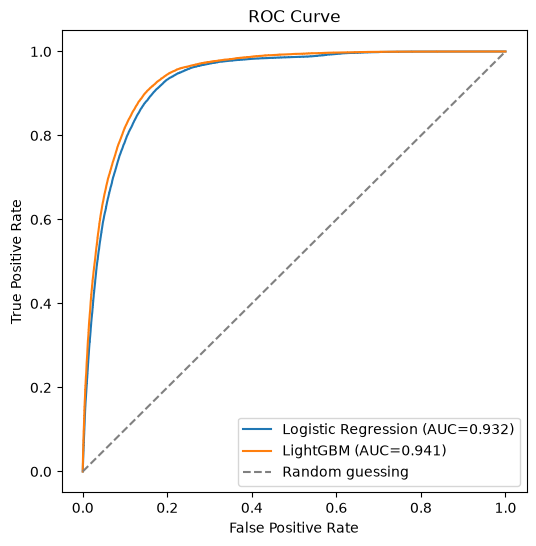

In [11]:
plt.figure(figsize=(6, 6))
for name, probs in [("Logistic Regression", valid_probs_logreg), ("LightGBM", valid_probs_lgb)]:
    fpr, tpr, _ = roc_curve(y_valid, probs)
    auc = roc_auc_score(y_valid, probs)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random guessing")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


The closer a curve hugs the top-left corner, the better: it means the model achieves a high true-positive rate while keeping the false-positive rate low. The diagonal dashed line is what a random-guessing model would produce (AUC = 0.5) — our baseline.


## 8. Cross-validation: a more reliable score estimate

A single train/validation split gives one estimate of model performance, but that estimate has some luck baked in — a different random split could give a noticeably different score, especially with class imbalance.

**K-fold cross-validation** fixes this: split the training data into *K* equal folds (we'll use K=5). For each fold in turn, train on the other K-1 folds and validate on that one held-out fold. Average the K validation scores for a much more stable estimate — and every row gets used for both training and validation at some point.

We use `StratifiedKFold` (not plain `KFold`) so each fold preserves the ~17.5% positive rate, same reasoning as the earlier stratified split.


In [12]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

X_full = train[feature_cols].copy()
for col in categorical_features:
    X_full[col] = X_full[col].astype("category")
y_full = (train[TARGET] == "Yes").astype(int)

oof_preds = np.zeros(len(X_full))
fold_models = []
fold_aucs = []

for fold, (train_idx, valid_idx) in enumerate(skf.split(X_full, y_full)):
    X_tr, X_val = X_full.iloc[train_idx], X_full.iloc[valid_idx]
    y_tr, y_val = y_full.iloc[train_idx], y_full.iloc[valid_idx]

    ds_tr = lgb.Dataset(X_tr, label=y_tr, categorical_feature=categorical_features)
    ds_val = lgb.Dataset(X_val, label=y_val, categorical_feature=categorical_features, reference=ds_tr)

    model = lgb.train(
        params,
        ds_tr,
        num_boost_round=1000,
        valid_sets=[ds_val],
        callbacks=[lgb.early_stopping(stopping_rounds=50), lgb.log_evaluation(period=0)],
    )

    fold_pred = model.predict(X_val, num_iteration=model.best_iteration)
    oof_preds[valid_idx] = fold_pred
    fold_auc = roc_auc_score(y_val, fold_pred)
    fold_aucs.append(fold_auc)
    fold_models.append(model)
    print(f"Fold {fold}: AUC = {fold_auc:.4f}  (best_iteration={model.best_iteration})")

print()
print(f"Mean CV AUC: {np.mean(fold_aucs):.4f} +/- {np.std(fold_aucs):.4f}")
print(f"Overall OOF AUC: {roc_auc_score(y_full, oof_preds):.4f}")


Training until validation scores don't improve for 50 rounds


Early stopping, best iteration is:
[440]	valid_0's auc: 0.94032
Fold 0: AUC = 0.9403  (best_iteration=440)


Training until validation scores don't improve for 50 rounds


Early stopping, best iteration is:
[281]	valid_0's auc: 0.941252
Fold 1: AUC = 0.9413  (best_iteration=281)


Training until validation scores don't improve for 50 rounds


...

Training until validation scores don't improve for 50 rounds


Early stopping, best iteration is:
[516]	valid_0's auc: 0.942187
Fold 3: AUC = 0.9422  (best_iteration=516)


Training until validation scores don't improve for 50 rounds


Early stopping, best iteration is:
[500]	valid_0's auc: 0.941621
Fold 4: AUC = 0.9416  (best_iteration=500)

Mean CV AUC: 0.9416 +/- 0.0008


Overall OOF AUC: 0.9416


`oof_preds` are **out-of-fold predictions**: for every training row, the prediction from the one fold-model that never saw that row during training. The "Overall OOF AUC" computed from these is our best single estimate of how the model will score on the real, hidden test set — this is the number we should trust most, more than any single train/valid split.


## 9. Generate the submission file

We now have 5 trained fold-models. Rather than picking just one, we **average their predictions** on the test set — a simple form of ensembling that usually reduces variance and improves the final score slightly, since each fold-model saw a slightly different 80% slice of the data.


In [13]:
X_test = test[feature_cols].copy()
for col in categorical_features:
    X_test[col] = X_test[col].astype("category")

test_preds = np.zeros(len(X_test))
for model in fold_models:
    test_preds += model.predict(X_test, num_iteration=model.best_iteration) / len(fold_models)

submission = pd.DataFrame({
    ID_COL: test[ID_COL],
    TARGET: test_preds,
})
submission.to_csv("../submissions/lgb_baseline.csv", index=False)
submission.head()


,id,Will_Buy_EV
0,668665,0.009333
1,668666,0.019815
2,668667,0.005229
3,668668,0.002815
4,668669,0.018383


## 10. What's next?

This is a solid, honest baseline — no leakage, a trustworthy cross-validated score, and a submission ready to go. From here, typical next steps to improve the score (roughly in order of effort/impact):

1. **Hyperparameter tuning** — search over `num_leaves`, `learning_rate`, `min_child_samples`, `feature_fraction`, etc. (e.g. with `optuna`).
2. **Feature engineering** — create new features from combinations of existing ones (e.g. `Annual_Income_USD / Daily_Commute_km`, or binning `Age`).
3. **Try XGBoost / CatBoost too** — different tree-boosting libraries sometimes pick up slightly different patterns; averaging (or stacking) multiple model types often beats any single one.
4. **More folds / repeated CV** — reduces variance in the score estimate further, at the cost of more compute.
5. **Feature importance analysis** (`lgb_model.feature_importance()`) — understand which features actually drive predictions, and consider dropping noisy ones.

To submit this file to Kaggle from the terminal:

```bash
kaggle competitions submit -c playground-series-s6e9 -f submissions/lgb_baseline.csv -m "LightGBM 5-fold baseline"
```
